# Cost function validation — ranking, shape, alignment

Tests the **currently active** cost function on the **real simulator only**. No GP, no policy, no
training. If the cost fails here it is the cost's fault, and no amount of model or optimiser work
can recover.

The imagined cost `J` cannot answer these questions: it is model-dependent, arbitrarily scaled, and
changes units whenever the cost changes, so it is uncomparable across candidates. This mirrors the
MC-PILCO paper, which optimises cost (19) but *reports* cost (20) plus a binary success rate.

### The three tests, and why the obvious version of each is wrong

**C.2 RANKING** — does the cost order batches the way `batch_yield_kg` does?

  *Naive version:* Spearman rho over all levels. **This is wrong here.** Yield is statistically
  FLAT across `a` in roughly [0, +0.6] (see C.2), so a plain rank correlation penalises the cost for
  discriminating between levels the data cannot actually separate. Instead we test **concordance on
  resolvable pairs only**: for every pair of action levels whose yields differ significantly
  (paired across seeds), does the cost order them correctly?

**C.3 SHAPE** — is there a usable gradient everywhere?

  *Naive version:* flag any level with near-zero slope. **This is wrong** because a smooth curve
  necessarily has zero slope AT its minimum. We exclude a neighbourhood of the argmin and look for
  flat regions away from it — a plateau is what stalls an optimiser, a minimum is what it is
  looking for.

**C.4 ALIGNMENT** — does the cost minimise where yield is maximised?

  *Naive version:* compare argmin of cost with argmax of yield. **This is wrong** when the yield
  curve is flat: its argmax is then just the luckiest point of a noisy plateau. We compute the
  **plateau** — every level not significantly worse than the best — and pass if the cost's argmin
  falls inside it.

**C.5 POSITIVE CONTROL** — the tests are themselves tested, by scoring a deliberately inverted cost
and confirming it fails. A test that cannot detect a broken cost is not testing anything.

### What is under test right now

`_terms` returns zeros for all three penalties, so the active cost is `-p_weight * P` summed over
the horizon: the **area under the concentration curve**. Not final concentration, not kilograms.
Being linear in `P`, it cannot exhibit the paper's peakedness failure — that would require a
saturating transform like `1 - exp(-(d/l)^2)`.

## C.0 Setup

In [1]:
%matplotlib inline
import os, sys, contextlib, io
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy import stats

import os as _os, sys as _sys
_ROOT = _os.path.dirname(_os.path.abspath(""))
_sys.path.insert(0, _ROOT)
_sys.path.insert(0, _os.path.dirname(_ROOT))

from mcpilco.pensim_wrapper import (PenSimWrapper, CONTROL_H, T_SAMPLING, STATE_NAMES,
                                    FS_SCALE, VISC_MAX, batch_yield_kg)
from mcpilco.penicillin_cost import PeniConcentrationCost

ALPHA = 0.05          # significance level for "are these two levels actually different?"
print("state:", STATE_NAMES, "| FS_SCALE =", FS_SCALE)

state: ['Wt', 'X', 'P', 'Viscosity', 'time'] | FS_SCALE = 0.5


## C.1 Config and sweep

21 constant action levels x 5 held-out seeds, **paired**: identical seeds at every level, so
level-to-level differences are attributable to the action rather than to batch realisation.

`FS_SCALE` sets what the action means (`Fs = Fs_recipe * (1 + FS_SCALE * a)`). At 0 the sweep would
be degenerate — every level is the recipe — so that is asserted rather than left to produce a
silently flat curve and a bogus "no gradient" verdict.

In [2]:
LEVELS = np.round(np.arange(-1.0, 1.0001, 0.1), 2)
SEEDS = [700000 + i for i in range(5)]
CACHE = Path(_ROOT) / "results" / "cost_shape_cache.csv"

assert FS_SCALE != 0, "FS_SCALE is 0 -- every action level collapses to the recipe; set it to 1.0"

# Bump this manually whenever the ACTIVE formula inside PeniConcentrationCost._terms() changes
# (e.g. a different commented-out reward block gets uncommented). CONFIG_TAG below fingerprints
# only the constructor kwargs, so it can't detect a code-level formula swap on its own -- a swap
# with unchanged kwargs would otherwise silently reuse rows computed under the old formula.
CACHE_SCHEMA_VERSION = "concentration_v1"

cost_kwargs = dict(p_weight=0.05, soft_penalty=0.5, rate_penalty=0.5,
                    visc_penalty=0.5, harvest_reward=True)
cost = PeniConcentrationCost(**cost_kwargs)
# Cache rows are keyed on (a, seed, CONFIG_TAG), not just (a, seed): otherwise editing p_weight
# / soft_penalty / rate_penalty / visc_penalty / harvest_reward above and re-running would find
# every (a, seed) pair already "cached" and silently serve reward/cost numbers computed under the
# OLD config -- every downstream test would then be reading stale numbers without any signal that
# anything was wrong.
CONFIG_TAG = CACHE_SCHEMA_VERSION + "|" + "|".join(f"{k}={v}" for k, v in sorted(cost_kwargs.items()))
print(f"p_weight={cost.p_weight} | {len(LEVELS)} levels x {len(SEEDS)} seeds "
      f"= {len(LEVELS) * len(SEEDS)} batches | config={CONFIG_TAG}")


def score(states, inputs, cost_obj=None):
    '''Sum each cost term over one real batch (single "particle").

    Step 0 is dropped: rollout writes states[0] only inside its `not pid_baseline` branch, and
    normalised zero is not a null state -- it decodes to the midpoint of every range. Dropping it
    uniformly keeps every row on the same footing.
    '''
    c = cost_obj or cost
    st = torch.tensor(np.asarray(states), dtype=torch.float64).unsqueeze(1)
    ins = torch.tensor(np.asarray(inputs), dtype=torch.float64).unsqueeze(1)
    with torch.no_grad():
        t = c._terms(st, ins)
    return {k: float(v[1:].sum()) for k, v in t.items()}


_cache = pd.read_csv(CACHE) if CACHE.exists() else pd.DataFrame()
if len(_cache) and "config" not in _cache.columns:
    # Pre-existing cache predates config-tagging. Every row currently on disk was in fact
    # generated under today's CONFIG_TAG (verified: constant reward/sum_P ratio across all
    # rows), so backfill rather than force a wasteful recompute of identical data. Any FUTURE
    # config change is what the (a, seed, config) key below is guarding against.
    #
    # Persist the migration IMMEDIATELY, not just in this run's in-memory _cache: the write
    # below at `if rows:` only fires when new rows were computed, which is exactly NOT the case
    # on a pure migration run (0 new batches needed). Skipping this write would leave the CSV on
    # disk untagged, so a later run under a genuinely DIFFERENT config would re-read the
    # untagged file and wrongly backfill it as "current" again -- silently defeating this fix.
    _cache["config"] = CONFIG_TAG
    _cache.to_csv(CACHE, index=False)

rows, wrapper = [], PenSimWrapper()
todo = [(a, s) for a in LEVELS for s in SEEDS
        if not (len(_cache) and
                ((_cache.a == a) & (_cache.seed == s) & (_cache.config == CONFIG_TAG)).any())]
print(f"{len(todo)} new batches to run ({len(LEVELS) * len(SEEDS) - len(todo)} cached)")

for i, (a, s) in enumerate(todo):
    with contextlib.redirect_stdout(io.StringIO()):
        st, ins, _ = wrapper.rollout(None, lambda _s, _i, _a=float(a): np.array([_a]),
                                     CONTROL_H, T_SAMPLING, 0, seed=int(s))
    mon = wrapper.monitor[-1]
    P = np.asarray(mon["P"])
    t = score(st, ins)
    rows.append({"a": a, "seed": s, "config": CONFIG_TAG,
                 "cost": -t["reward"] + t["soft"] + t["visc_soft"] + t["action_rate"],
                 "yield_kg": batch_yield_kg(mon), "final_P": float(P[-1]),
                 "sum_P": float(P.sum()), "max_visc": float(np.max(mon["Viscosity"])), **t})
    if (i + 1) % 20 == 0:
        print(f"  {i + 1}/{len(todo)}")

if rows:
    _cache = (pd.concat([_cache, pd.DataFrame(rows)], ignore_index=True)
              if len(_cache) else pd.DataFrame(rows))
    _cache.to_csv(CACHE, index=False)

df = _cache[_cache.a.isin(LEVELS) & _cache.seed.isin(SEEDS) & (_cache.config == CONFIG_TAG)].copy()
g = df.groupby("a").agg(cost=("cost", "mean"), cost_sd=("cost", "std"),
                        yield_kg=("yield_kg", "mean"), yield_sd=("yield_kg", "std"),
                        max_visc=("max_visc", "mean")).reset_index()
# Paired pivots: rows = seeds, columns = levels. Every downstream test is paired on these.
PY = df.pivot_table(index="seed", columns="a", values="yield_kg")
PC = df.pivot_table(index="seed", columns="a", values="cost")
print(f"\n{len(df)} rows | cost range [{g.cost.min():.1f}, {g.cost.max():.1f}]")
g.round(2)

p_weight=0.05 | 21 levels x 5 seeds = 105 batches | config=concentration_v1|harvest_reward=True|p_weight=0.05|rate_penalty=0.5|soft_penalty=0.5|visc_penalty=0.5
0 new batches to run (105 cached)

105 rows | cost range [-32.1, -17.8]


,a,cost,cost_sd,yield_kg,yield_sd,max_visc
0,-1.0,-25.60,1.71,2403.72,117.81,64.31
1,-0.9,-26.40,1.82,2517.71,127.35,66.07
2,-0.8,-27.14,1.89,2629.76,134.17,67.74
3,-0.7,-27.87,1.98,2743.15,143.50,69.34
4,-0.6,-28.59,2.08,2856.15,153.00,70.90
5,-0.5,-29.29,2.17,2968.63,162.15,72.41
6,-0.4,-29.97,2.25,3080.67,171.42,73.88
7,-0.3,-30.62,2.32,3192.57,180.61,75.27
8,-0.2,-31.26,2.40,3303.90,189.86,76.64
9,-0.1,-31.84,2.42,3413.91,196.40,77.95


### Sanity checks

`a = 0` must reproduce the recipe exactly (`Fs * (1 + FS_SCALE * 0)`). If it does not, the sweep is
wrong and nothing below means anything.

`feed_sweep_ceiling` shares levels -1.0 / 0.0 / +1.0 on the same seeds — but **only if it was run at
the same `FS_SCALE`**. A mismatch there is a configuration difference, not a defect.

In [3]:
with contextlib.redirect_stdout(io.StringIO()):
    rec = {}
    for s in SEEDS:
        wrapper.rollout(None, None, CONTROL_H, T_SAMPLING, 0, seed=int(s), pid_baseline=True)
        rec[s] = batch_yield_kg(wrapper.monitor[-1])
err = max(abs(PY.loc[s, 0.0] - rec[s]) for s in SEEDS)
print(f"[{'OK' if err < 1.0 else 'FAIL'}] a=0 reproduces the recipe: max |diff| = {err:.3f} kg")

_ceil = Path(_ROOT) / "results/feed_sweep_ceiling/per_arm_seed.csv"
if _ceil.exists():
    c_ = pd.read_csv(_ceil)
    c_["a"] = c_.arm.str.extract(r"a=([+-][\d.]+)").astype(float)
    for a in (-1.0, 0.0, 1.0):
        m = c_[(c_.a == a) & (c_.seed.isin(SEEDS))].set_index("seed")["yield_kg"]
        if len(m):
            d_ = max(abs(m[s] - PY.loc[s, a]) for s in m.index if s in PY.index)
            tag = "OK" if d_ < 1.0 else "DIFFERS"
            print(f"[{tag}] a={a:+.1f} vs feed_sweep_ceiling: max |diff| = {d_:.1f} kg"
                  + ("   <- expected if that sweep ran at a different FS_SCALE" if d_ >= 1.0 else ""))
else:
    print("(no feed_sweep_ceiling results to cross-check)")

[OK] a=0 reproduces the recipe: max |diff| = 0.000 kg
[DIFFERS] a=-1.0 vs feed_sweep_ceiling: max |diff| = 1314.9 kg   <- expected if that sweep ran at a different FS_SCALE
[OK] a=+0.0 vs feed_sweep_ceiling: max |diff| = 0.0 kg
[DIFFERS] a=+1.0 vs feed_sweep_ceiling: max |diff| = 3731.2 kg   <- expected if that sweep ran at a different FS_SCALE


## C.2 RANKING — concordance on resolvable pairs

For every pair of action levels, a paired t-test across the 5 seeds asks whether their yields are
**actually distinguishable**. Only those pairs can support a claim about ranking; on the rest the
truth itself is undecided, so the cost cannot be wrong about them.

For each resolvable pair we then check the cost disagrees in sign (cost is minimised, yield
maximised). **Pass: >= 95% concordance.**

Plain Spearman rho is also printed for reference, but it is the wrong statistic here — it charges
the cost for ordering pairs that yield cannot order.

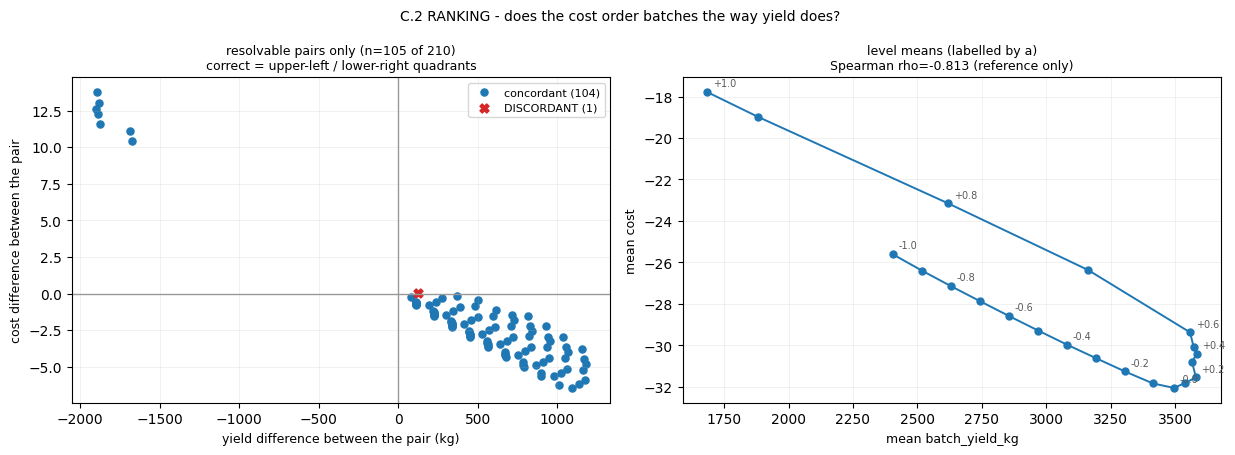

resolvable pairs : 105 of 210 (paired t-test p < 0.05)
concordance      : 99.0%

discordant pairs (cost prefers the LOWER-yield level):
  ai  aj      dy    dc     p
-0.1 0.1 126.193 0.032 0.041


In [4]:
levels = list(PY.columns)
pairs = []
for i, ai in enumerate(levels):
    for aj in levels[i + 1:]:
        _, p = stats.ttest_rel(PY[aj], PY[ai])
        pairs.append({"ai": ai, "aj": aj, "dy": PY[aj].mean() - PY[ai].mean(),
                      "dc": PC[aj].mean() - PC[ai].mean(), "p": p})
pairs = pd.DataFrame(pairs)
res = pairs[pairs.p < ALPHA].copy()
res["concordant"] = np.sign(res.dy) == -np.sign(res.dc)
conc = res.concordant.mean() if len(res) else np.nan
rho_ref, _ = stats.spearmanr(g["cost"], g["yield_kg"])

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
a_ = ax[0]
a_.scatter(res[res.concordant].dy, res[res.concordant].dc, s=26, color="C0",
           label=f"concordant ({int(res.concordant.sum())})")
a_.scatter(res[~res.concordant].dy, res[~res.concordant].dc, s=42, color="C3",
           marker="X", label=f"DISCORDANT ({int((~res.concordant).sum())})")
a_.axhline(0, color="0.6", lw=1); a_.axvline(0, color="0.6", lw=1)
a_.set_xlabel("yield difference between the pair (kg)", fontsize=9)
a_.set_ylabel("cost difference between the pair", fontsize=9)
a_.set_title(f"resolvable pairs only (n={len(res)} of {len(pairs)})\n"
             "correct = upper-left / lower-right quadrants", fontsize=9)
a_.grid(alpha=.25, lw=.5); a_.legend(fontsize=8)

a_ = ax[1]
a_.plot(g["yield_kg"], g["cost"], "-o", color="C0", lw=1.4, ms=5)
for _, r in g.iterrows():
    if abs(r["a"] * 10) % 2 < 1e-9:
        a_.annotate(f"{r['a']:+.1f}", (r["yield_kg"], r["cost"]), fontsize=7,
                    xytext=(4, 4), textcoords="offset points", color="0.35")
a_.set_xlabel("mean batch_yield_kg", fontsize=9); a_.set_ylabel("mean cost", fontsize=9)
a_.set_title(f"level means (labelled by a)\nSpearman rho={rho_ref:.3f} (reference only)", fontsize=9)
a_.grid(alpha=.25, lw=.5)

fig.suptitle("C.2 RANKING - does the cost order batches the way yield does?", fontsize=10)
fig.tight_layout(); plt.show()

print(f"resolvable pairs : {len(res)} of {len(pairs)} (paired t-test p < {ALPHA})")
print(f"concordance      : {100 * conc:.1f}%")
if len(res) and not res.concordant.all():
    print("\ndiscordant pairs (cost prefers the LOWER-yield level):")
    print(res[~res.concordant][["ai", "aj", "dy", "dc", "p"]].round(3).to_string(index=False))

In [5]:
# Robustness check: 210 pairwise t-tests at ALPHA=0.05, uncorrected, so ~10 false positives
# are expected by chance alone before looking at a single number. Bonferroni-correct alpha to
# confirm the RANKING verdict above doesn't hinge on one of those false positives (e.g. the
# a=-0.1 vs a=0.1 pair, which sits right at the flat cost minimum and is only marginally
# significant at p~0.04 uncorrected).
alpha_bonf = ALPHA / len(pairs)
res_bonf = pairs[pairs.p < alpha_bonf].copy()
res_bonf["concordant"] = np.sign(res_bonf.dy) == -np.sign(res_bonf.dc)
conc_bonf = res_bonf.concordant.mean() if len(res_bonf) else np.nan

print(f"Bonferroni-corrected alpha = {alpha_bonf:.2e}  (0.05 / {len(pairs)} pairs)")
print(f"resolvable pairs : {len(res_bonf)} of {len(pairs)}")
print(f"concordance      : {100 * conc_bonf:.1f}%   "
      f"({'PASS' if conc_bonf >= 0.95 else 'FAIL'})")
if len(res) != len(res_bonf):
    print(f"\n{len(res) - len(res_bonf)} pair(s) resolvable at alpha={ALPHA} drop out under "
          "correction -- the primary verdict above still uses the uncorrected bar; this cell "
          "is a robustness check on it, not a replacement.")

Bonferroni-corrected alpha = 2.38e-04  (0.05 / 210 pairs)
resolvable pairs : 62 of 210
concordance      : 100.0%   (PASS)

43 pair(s) resolvable at alpha=0.05 drop out under correction -- the primary verdict above still uses the uncorrected bar; this cell is a robustness check on it, not a replacement.


## C.3 SHAPE — is there a usable gradient away from the optimum?

A smooth curve has zero slope **at** its minimum; that is the target, not a defect. So flatness is
only tested outside a neighbourhood of the argmin. What stalls an optimiser is a *plateau* — a wide
region with no slope to descend.

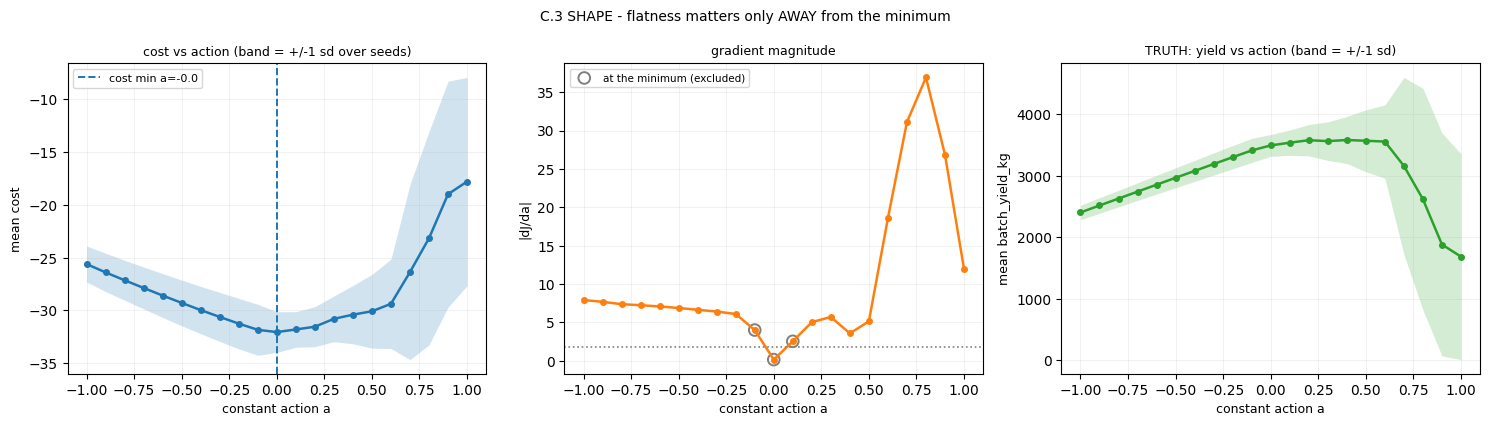

|dJ/da| in [0.16, 36.92]; plateau levels away from the minimum: none


In [6]:
a_grid = g["a"].values
cost_m, cost_s = g["cost"].values, g["cost_sd"].values
slope = np.gradient(cost_m, a_grid)
i_min = int(cost_m.argmin())

# Exclude +/-1 grid step around the minimum: zero slope there is the definition of a minimum.
near_min = np.zeros_like(a_grid, dtype=bool)
near_min[max(0, i_min - 1):i_min + 2] = True
flat = (np.abs(slope) < 0.05 * np.abs(slope).max()) & ~near_min

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
a_ = ax[0]
a_.fill_between(a_grid, cost_m - cost_s, cost_m + cost_s, color="C0", alpha=.2, lw=0)
a_.plot(a_grid, cost_m, "-o", color="C0", lw=1.8, ms=4)
a_.axvline(a_grid[i_min], color="C0", ls="--", lw=1.4, label=f"cost min a={a_grid[i_min]:+.1f}")
a_.set_xlabel("constant action a", fontsize=9); a_.set_ylabel("mean cost", fontsize=9)
a_.set_title("cost vs action (band = +/-1 sd over seeds)", fontsize=9)
a_.grid(alpha=.25, lw=.5); a_.legend(fontsize=8)

a_ = ax[1]
a_.plot(a_grid, np.abs(slope), "-o", color="C1", lw=1.8, ms=4)
a_.scatter(a_grid[near_min], np.abs(slope)[near_min], s=70, facecolor="none",
           edgecolor="0.5", lw=1.4, label="at the minimum (excluded)")
if flat.any():
    a_.scatter(a_grid[flat], np.abs(slope)[flat], s=90, facecolor="none", edgecolor="C3",
               lw=1.8, zorder=5, label="PLATEAU - optimiser stalls")
a_.axhline(0.05 * np.abs(slope).max(), color="0.5", ls=":", lw=1.2)
a_.set_xlabel("constant action a", fontsize=9); a_.set_ylabel("|dJ/da|", fontsize=9)
a_.set_title("gradient magnitude", fontsize=9)
a_.grid(alpha=.25, lw=.5); a_.legend(fontsize=7.5)

a_ = ax[2]
a_.fill_between(a_grid, g["yield_kg"] - g["yield_sd"], g["yield_kg"] + g["yield_sd"],
                color="C2", alpha=.2, lw=0)
a_.plot(a_grid, g["yield_kg"], "-o", color="C2", lw=1.8, ms=4)
a_.set_xlabel("constant action a", fontsize=9)
a_.set_ylabel("mean batch_yield_kg", fontsize=9)
a_.set_title("TRUTH: yield vs action (band = +/-1 sd)", fontsize=9)
a_.grid(alpha=.25, lw=.5)

fig.suptitle("C.3 SHAPE - flatness matters only AWAY from the minimum", fontsize=10)
fig.tight_layout(); plt.show()
print(f"|dJ/da| in [{np.abs(slope).min():.2f}, {np.abs(slope).max():.2f}]; "
      f"plateau levels away from the minimum: {list(a_grid[flat]) if flat.any() else 'none'}")

## C.4 ALIGNMENT — does the cost minimise inside the yield optimum?

The yield curve is flat over a wide range of `a`, so its argmax is largely which point got the
luckiest seeds. Comparing the cost's argmin to that single point tests noise.

Instead we compute the **plateau**: every level whose yield is not significantly *worse* than the
best level, paired across seeds. **Pass: the cost's argmin lies inside the plateau** — i.e. the cost
picks an action that is not measurably worse than the best available.

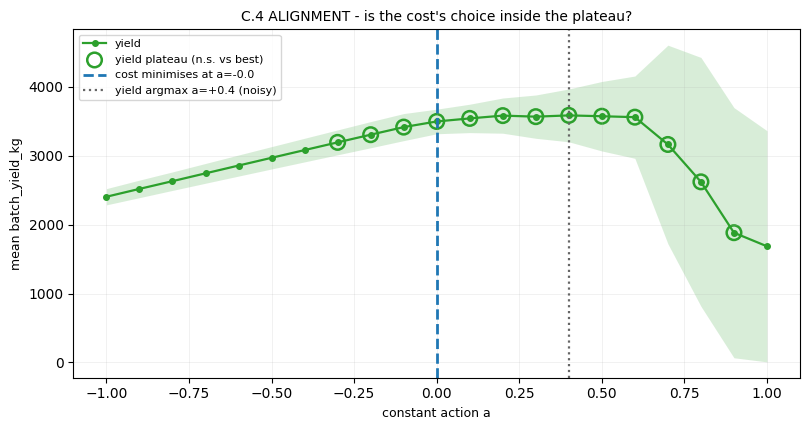

yield plateau (not significantly worse than a=+0.4): [-0.3, -0.2, -0.1, -0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
cost minimises at a=-0.0 -> INSIDE the plateau

variance across the plateau (a policy should prefer the low-variance end):
   a=-0.3: yield    3193 +/-    181 kg
   a=-0.2: yield    3304 +/-    190 kg
   a=-0.1: yield    3414 +/-    196 kg
   a=-0.0: yield    3496 +/-    178 kg
   a=+0.1: yield    3540 +/-    206 kg
   a=+0.2: yield    3581 +/-    255 kg
   a=+0.3: yield    3566 +/-    314 kg
   a=+0.4: yield    3584 +/-    383 kg
   a=+0.5: yield    3572 +/-    504 kg
   a=+0.6: yield    3558 +/-    597 kg
   a=+0.7: yield    3162 +/-   1441 kg
   a=+0.8: yield    2620 +/-   1805 kg
   a=+0.9: yield    1882 +/-   1815 kg


In [7]:
a_best = g.loc[g["yield_kg"].idxmax(), "a"]
plateau = []
for a in levels:
    if a == a_best:
        plateau.append(a); continue
    _, p = stats.ttest_rel(PY[a_best], PY[a])
    if p >= ALPHA:
        plateau.append(a)
a_cost = a_grid[i_min]
in_plateau = a_cost in plateau

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.fill_between(a_grid, g["yield_kg"] - g["yield_sd"], g["yield_kg"] + g["yield_sd"],
                color="C2", alpha=.18, lw=0)
ax.plot(a_grid, g["yield_kg"], "-o", color="C2", lw=1.6, ms=4, label="yield")
ax.scatter(plateau, [g.loc[g.a == a, "yield_kg"].iloc[0] for a in plateau], s=110,
           facecolor="none", edgecolor="C2", lw=1.8, label="yield plateau (n.s. vs best)")
ax.axvline(a_cost, color="C0", ls="--", lw=2, label=f"cost minimises at a={a_cost:+.1f}")
ax.axvline(a_best, color="0.4", ls=":", lw=1.6, label=f"yield argmax a={a_best:+.1f} (noisy)")
ax.set_xlabel("constant action a", fontsize=9)
ax.set_ylabel("mean batch_yield_kg", fontsize=9)
ax.set_title("C.4 ALIGNMENT - is the cost's choice inside the plateau?", fontsize=10)
ax.grid(alpha=.25, lw=.5); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"yield plateau (not significantly worse than a={a_best:+.1f}): {plateau}")
print(f"cost minimises at a={a_cost:+.1f} -> {'INSIDE' if in_plateau else 'OUTSIDE'} the plateau")
print("\nvariance across the plateau (a policy should prefer the low-variance end):")
for a in sorted(plateau):
    print(f"   a={a:+.1f}: yield {PY[a].mean():7.0f} +/- {PY[a].std(ddof=1):6.0f} kg")

## C.5 POSITIVE CONTROL — can these tests detect a broken cost?

A test that passes everything is worthless. We score a **deliberately inverted** cost (reward
negated, so it prefers *less* penicillin) on the same `(a, seed)` grid — re-simulated fresh, not
read from `cost_shape_cache.csv`, since the cache only stores the real cost's terms; `rollout`
reseeds `np.random` per call so this reproduces the exact same trajectories deterministically — and
confirm the ranking test rejects it. If the inverted cost also passes, the test is measuring nothing
and the verdicts above mean nothing.

**Caveat:** `InvertedCost` below only negates `reward`. That currently makes it an *exact* sign-flip
of the real cost, because `soft`/`visc_soft`/`action_rate` are hard-zeroed in `_terms()` right now —
see C.0. The moment any of those penalties is re-enabled, `InvertedCost` stops being an exact
negation (only `reward` flips sign; the penalties keep the same sign in both), so this section's
"guaranteed strong reject" property gets weaker. Re-run C.5 after re-enabling any penalty to confirm
it still rejects a broken cost.</cell id="96fce114">


In [8]:
class InvertedCost(PeniConcentrationCost):
    '''Same cost with the reward negated -- prefers LOW penicillin. Must fail C.2.'''
    def _terms(self, s, i, trial_index=None):
        t = super()._terms(s, i, trial_index)
        return {**t, "reward": -t["reward"]}


bad = InvertedCost(p_weight=0.05, soft_penalty=0.5, rate_penalty=0.5, visc_penalty=0.5)
bad_rows = []
for a in LEVELS:
    for s in SEEDS:
        with contextlib.redirect_stdout(io.StringIO()):
            st, ins, _ = wrapper.rollout(None, lambda _s, _i, _a=float(a): np.array([_a]),
                                         CONTROL_H, T_SAMPLING, 0, seed=int(s))
        t = score(st, ins, cost_obj=bad)
        bad_rows.append({"a": a, "seed": s,
                         "cost": -t["reward"] + t["soft"] + t["visc_soft"] + t["action_rate"]})
PCB = pd.DataFrame(bad_rows).pivot_table(index="seed", columns="a", values="cost")

bad_conc = []
for _, r in res.iterrows():
    dcb = PCB[r.aj].mean() - PCB[r.ai].mean()
    bad_conc.append(np.sign(r.dy) == -np.sign(dcb))
bad_conc = float(np.mean(bad_conc))

print(f"real cost     concordance: {100 * conc:6.1f}%   ({'PASS' if conc >= 0.95 else 'FAIL'})")
print(f"INVERTED cost concordance: {100 * bad_conc:6.1f}%   "
      f"({'correctly REJECTED' if bad_conc < 0.95 else 'WRONGLY ACCEPTED'})")
print()
if bad_conc < 0.95 < conc:
    print("[VALID]   the test separates a good cost from a broken one, so the verdicts mean something.")
elif bad_conc >= 0.95:
    print("[INVALID] the test accepts an inverted cost -- it is not measuring ranking at all.")
else:
    print("[CHECK]   both costs fail; the test may be too strict, or the real cost is genuinely broken.")

real cost     concordance:   99.0%   (PASS)
INVERTED cost concordance:    1.0%   (correctly REJECTED)

[VALID]   the test separates a good cost from a broken one, so the verdicts mean something.


## C.6 Verdict

In [9]:
rank_pass = (conc >= 0.95)
shape_pass = not flat.any()
align_pass = in_plateau

print("=" * 80)
print(f"[{'PASS' if rank_pass else 'FAIL'}] RANKING   {100 * conc:.1f}% concordance on "
      f"{len(res)} resolvable pairs (need >= 95%)")
if not rank_pass:
    print("       -> the cost prefers lower-yield batches among pairs the data CAN separate.")
    print("          Nothing downstream fixes this: the optimiser will faithfully minimise it.")

print(f"[{'PASS' if shape_pass else 'FAIL'}] SHAPE     "
      f"{int(flat.sum())} plateau level(s) away from the minimum; "
      f"|dJ/da| in [{np.abs(slope).min():.2f}, {np.abs(slope).max():.2f}]")
if not shape_pass:
    print("       -> a flat region gives the optimiser nothing to descend (paper section V-A).")

print(f"[{'PASS' if align_pass else 'FAIL'}] ALIGNMENT cost minimises at a={a_cost:+.1f}; "
      f"yield plateau is {plateau[0]:+.1f}..{plateau[-1]:+.1f}")
if not align_pass:
    print("       -> the cost's optimum is measurably worse than the best available action.")
print("=" * 80)

print(f"\nTest validity (C.5): inverted cost scored {100 * bad_conc:.1f}% "
      f"-- {'rejected, tests are live' if bad_conc < 0.95 else 'ACCEPTED, tests are broken'}")
print("\nNote: with penalties disabled the cost is -p_weight * sum(P) -- AREA UNDER the")
print("concentration curve, not kilograms. Report batch_yield_kg separately.")

[PASS] RANKING   99.0% concordance on 105 resolvable pairs (need >= 95%)
[PASS] SHAPE     0 plateau level(s) away from the minimum; |dJ/da| in [0.16, 36.92]
[PASS] ALIGNMENT cost minimises at a=-0.0; yield plateau is -0.3..+0.9

Test validity (C.5): inverted cost scored 1.0% -- rejected, tests are live

Note: with penalties disabled the cost is -p_weight * sum(P) -- AREA UNDER the
concentration curve, not kilograms. Report batch_yield_kg separately.
